# Reading NOAA tide gauges data

Data can be found here: https://www.ncei.noaa.gov/maps/hazards/?layers=5


/var/folders/rf/kb91cszd7812fjhk3dz0j0pr0000gn/T/ipykernel_69037/836725766.py:34: FutureWarning:

'T' is deprecated and will be removed in a future version, please use 'min' instead.



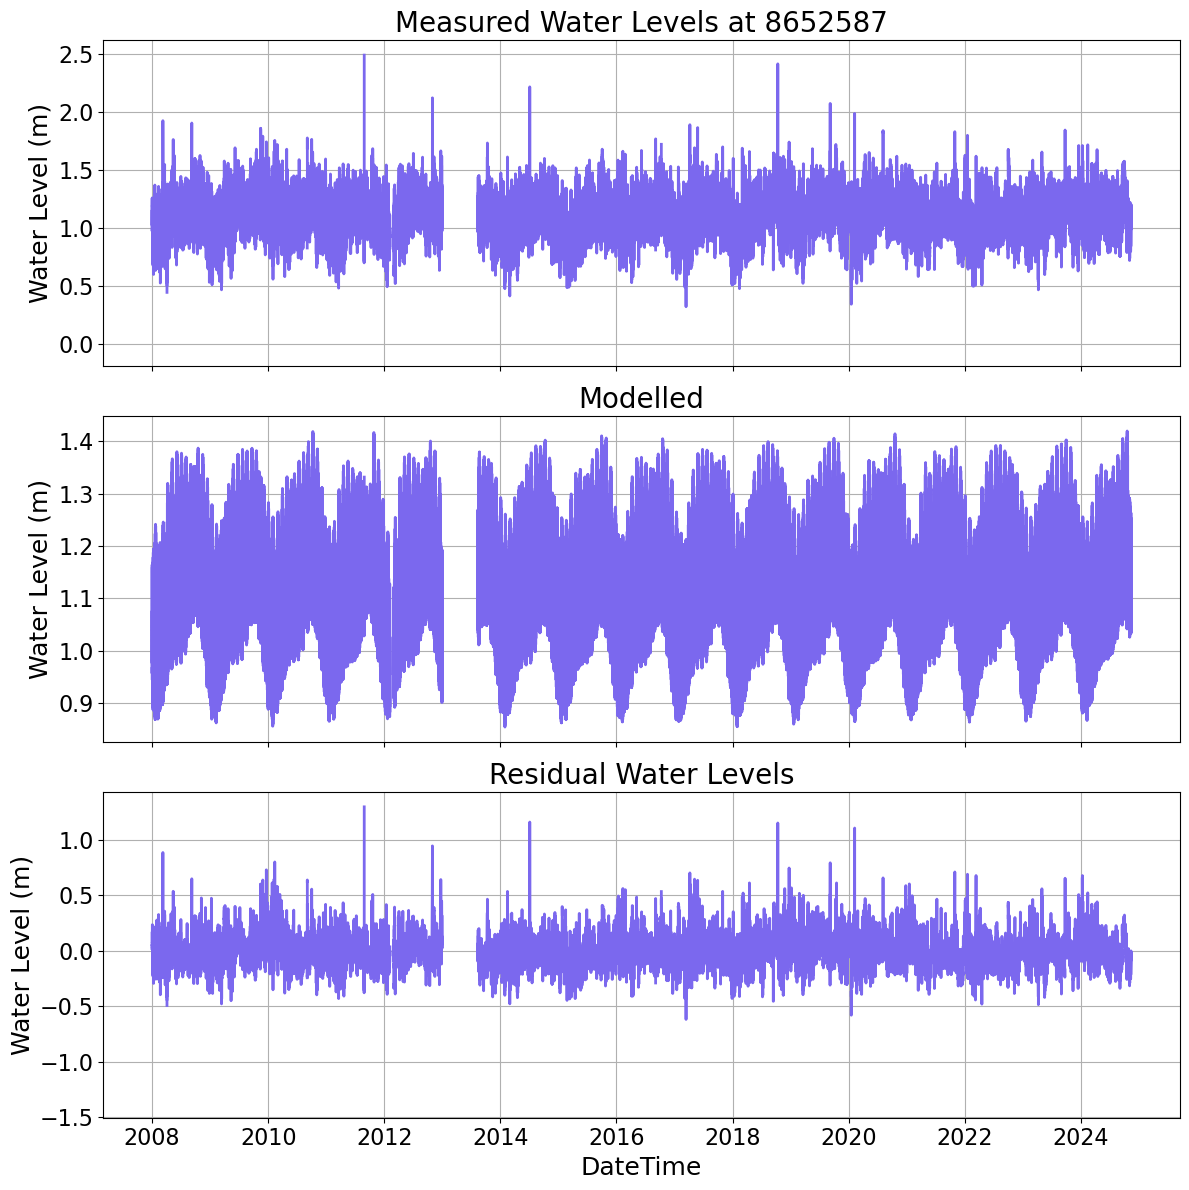

/var/folders/rf/kb91cszd7812fjhk3dz0j0pr0000gn/T/ipykernel_69037/836725766.py:34: FutureWarning:

'T' is deprecated and will be removed in a future version, please use 'min' instead.



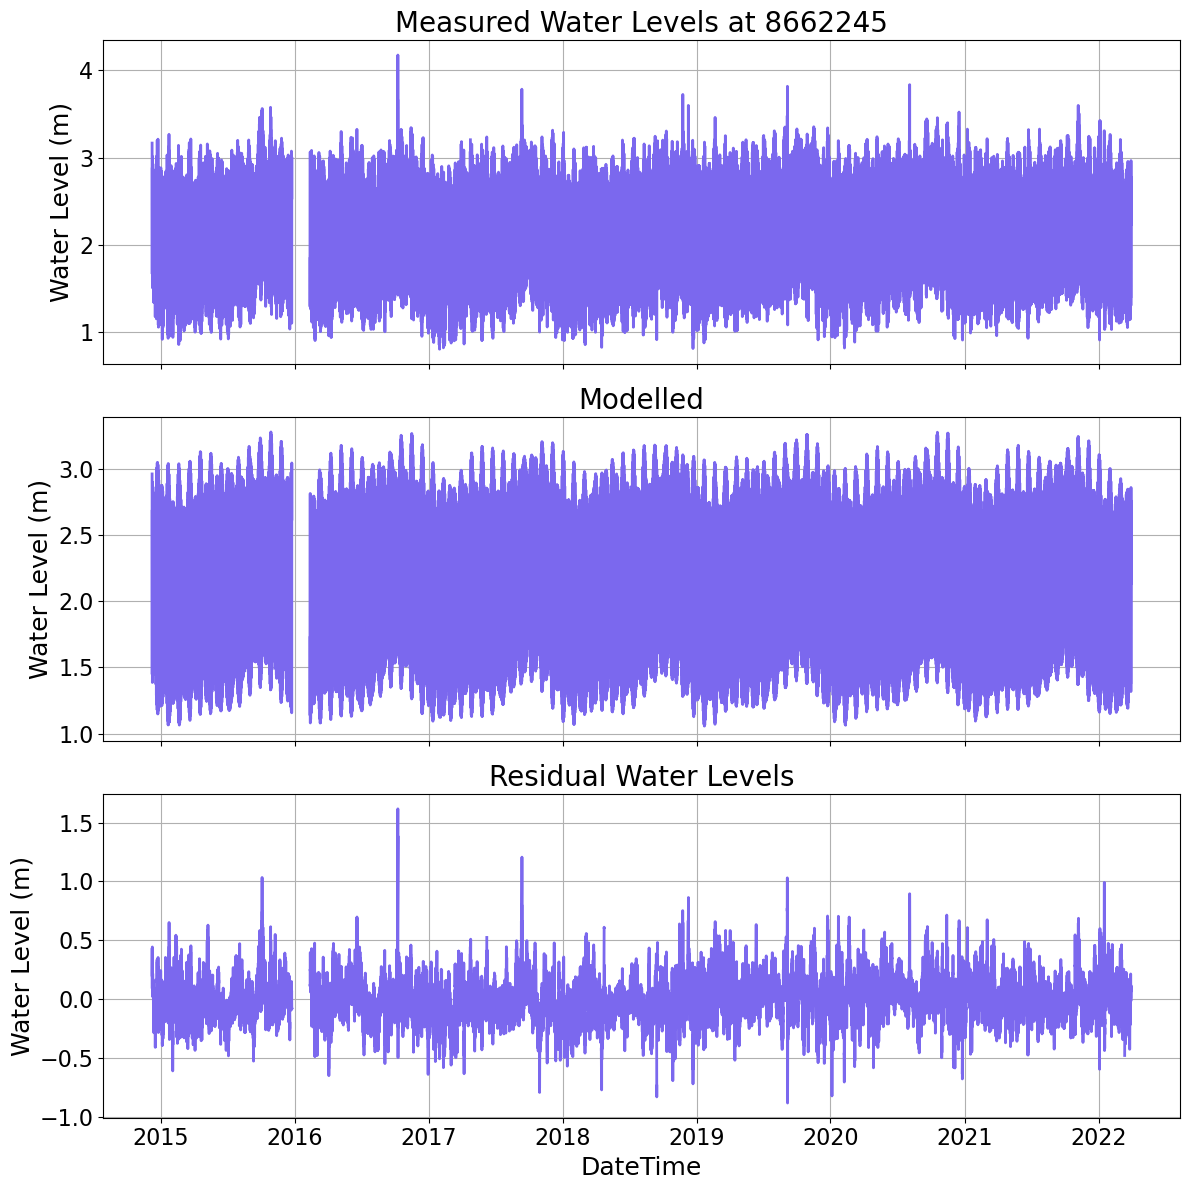

/var/folders/rf/kb91cszd7812fjhk3dz0j0pr0000gn/T/ipykernel_69037/836725766.py:34: FutureWarning:

'T' is deprecated and will be removed in a future version, please use 'min' instead.



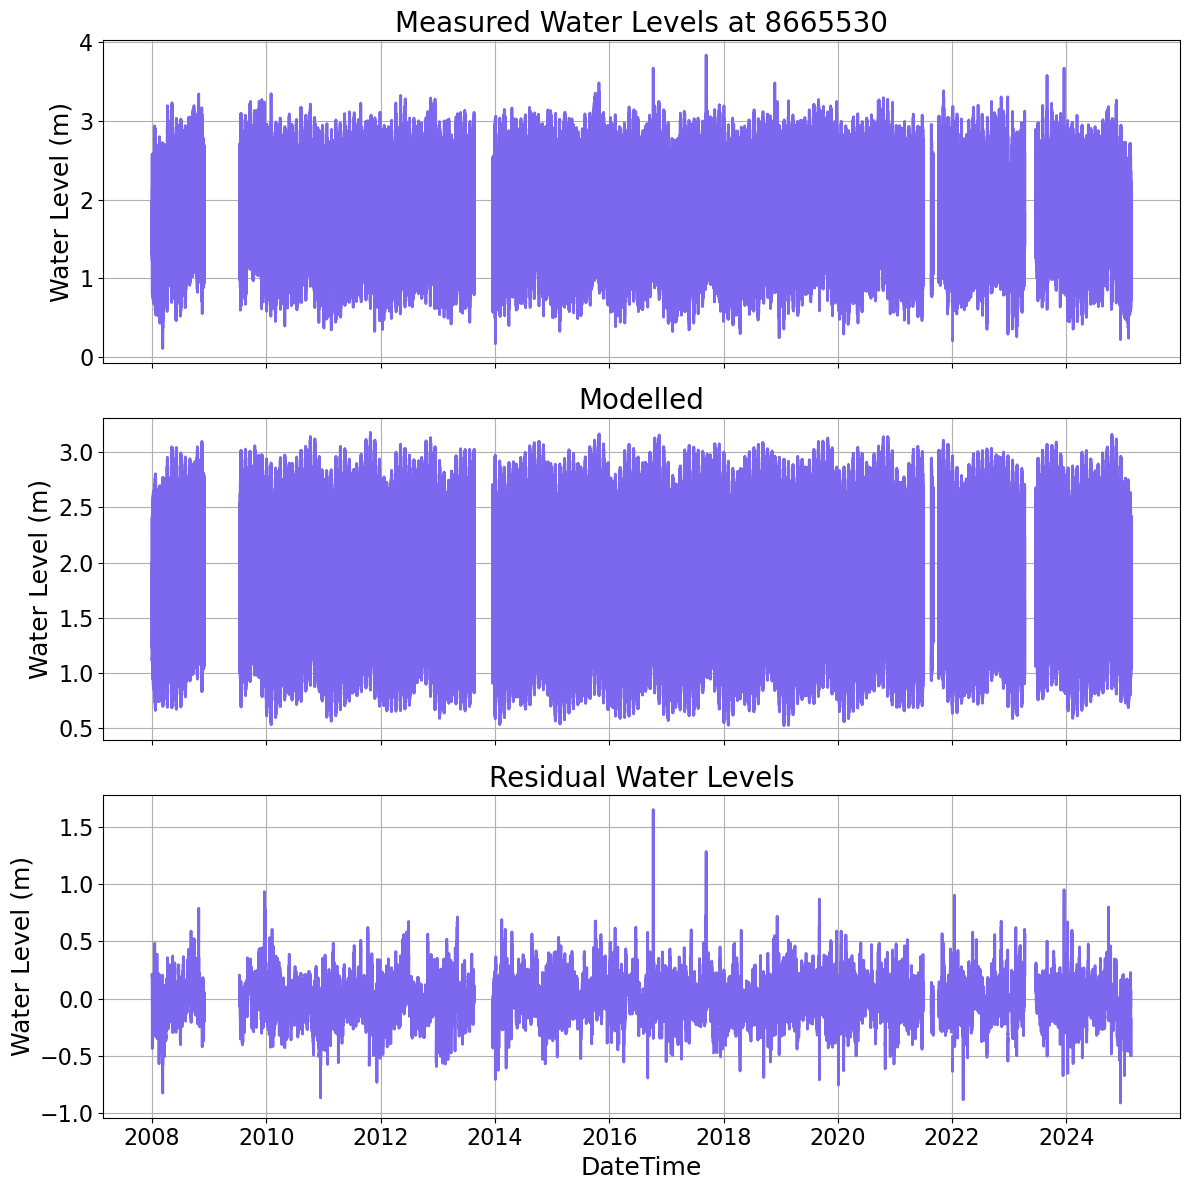

/var/folders/rf/kb91cszd7812fjhk3dz0j0pr0000gn/T/ipykernel_69037/836725766.py:34: FutureWarning:

'T' is deprecated and will be removed in a future version, please use 'min' instead.



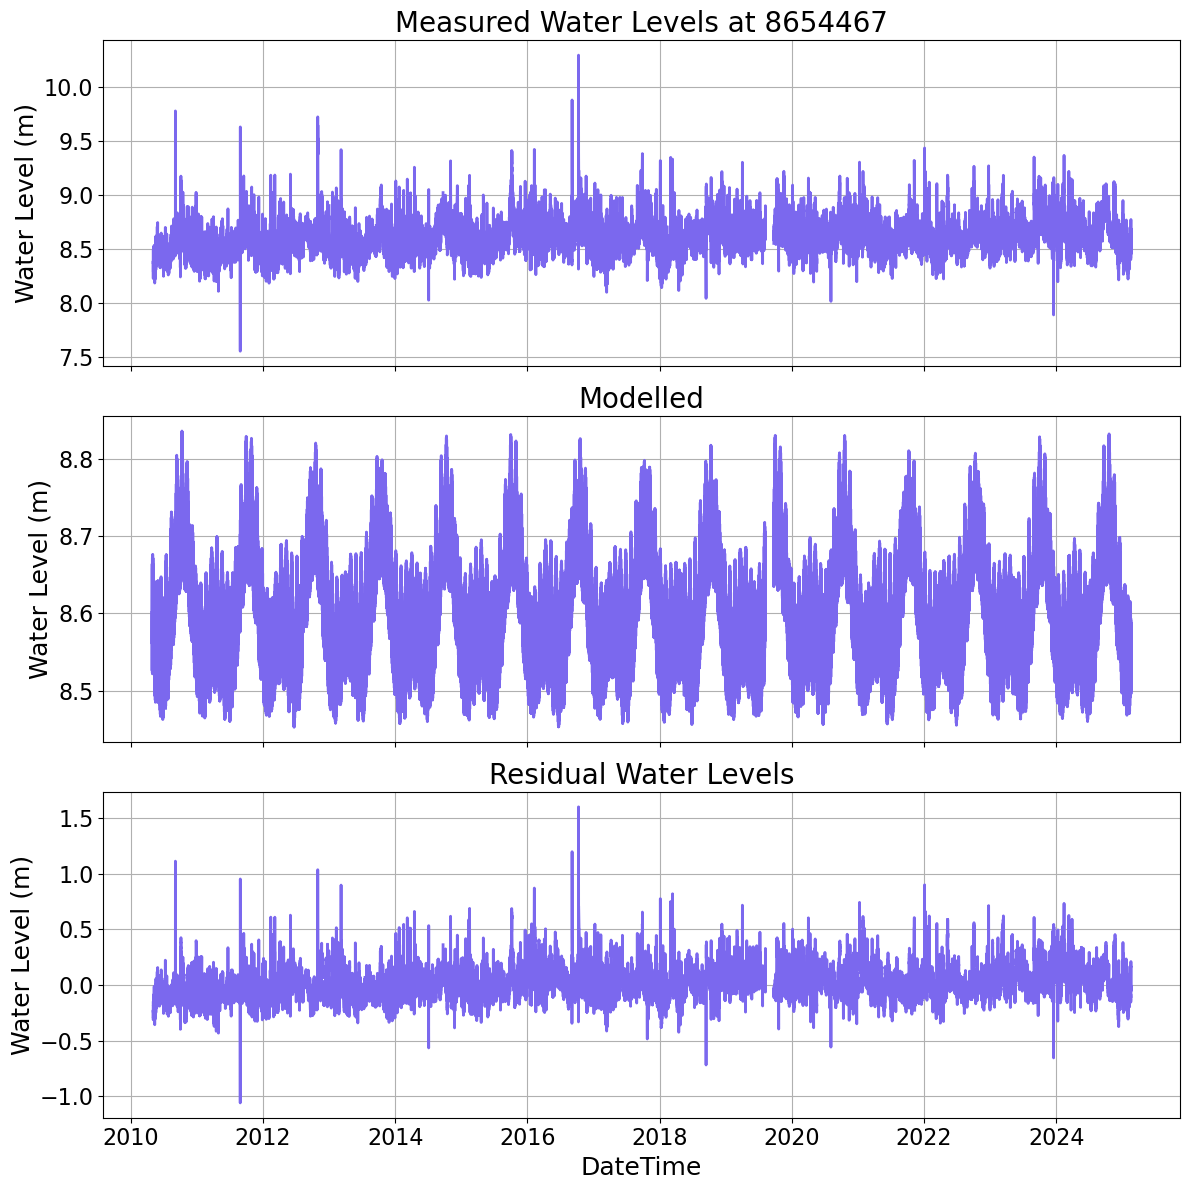

/var/folders/rf/kb91cszd7812fjhk3dz0j0pr0000gn/T/ipykernel_69037/836725766.py:34: FutureWarning:

'T' is deprecated and will be removed in a future version, please use 'min' instead.



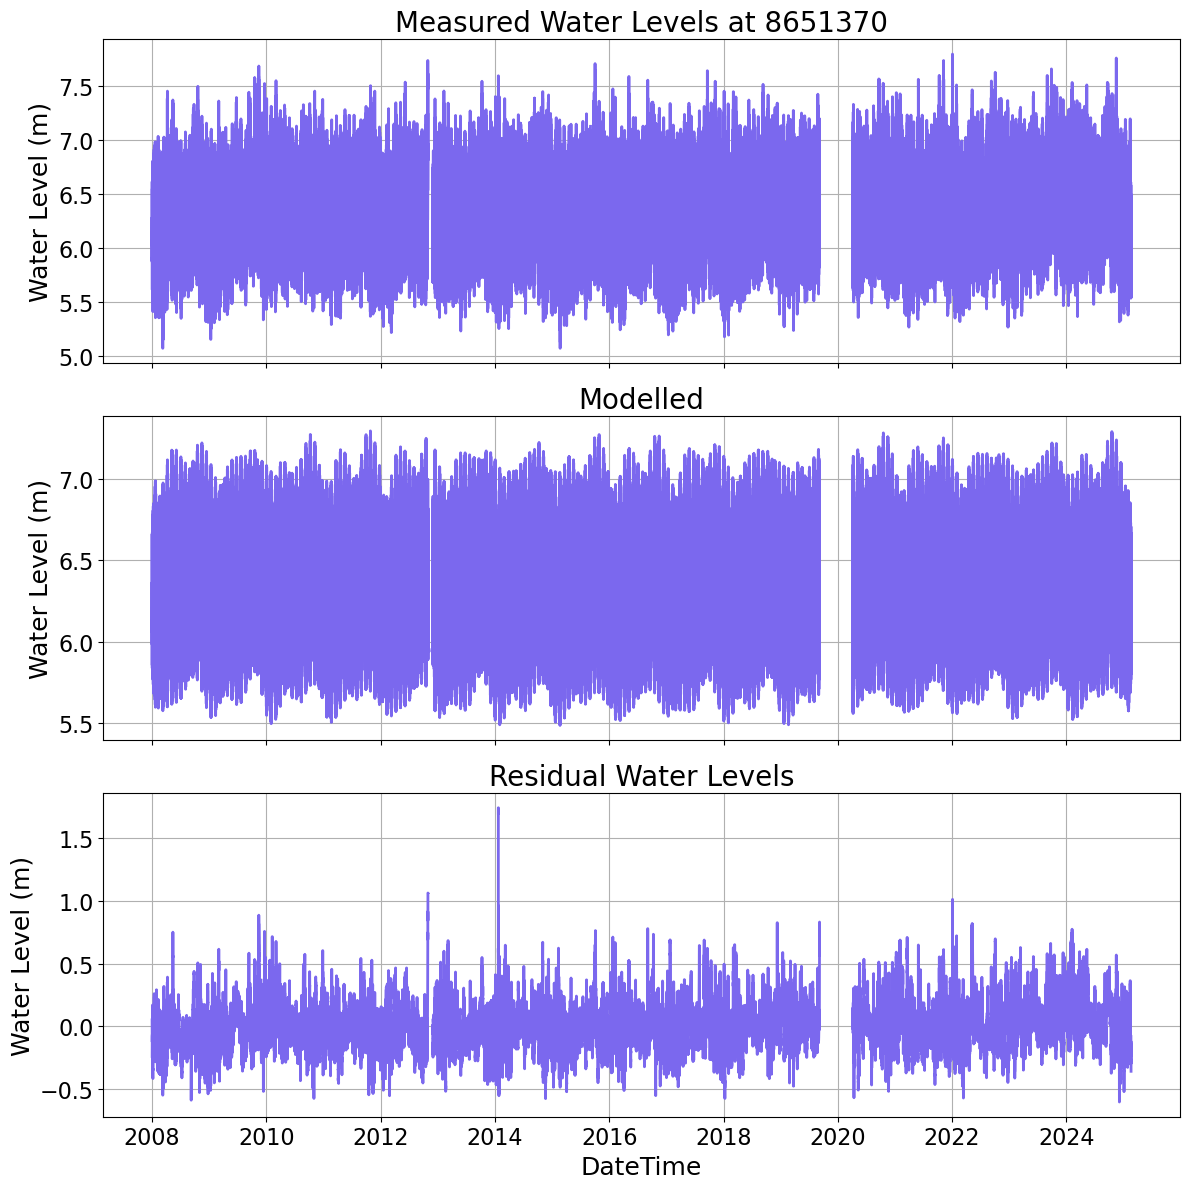

/var/folders/rf/kb91cszd7812fjhk3dz0j0pr0000gn/T/ipykernel_69037/836725766.py:34: FutureWarning:

'T' is deprecated and will be removed in a future version, please use 'min' instead.



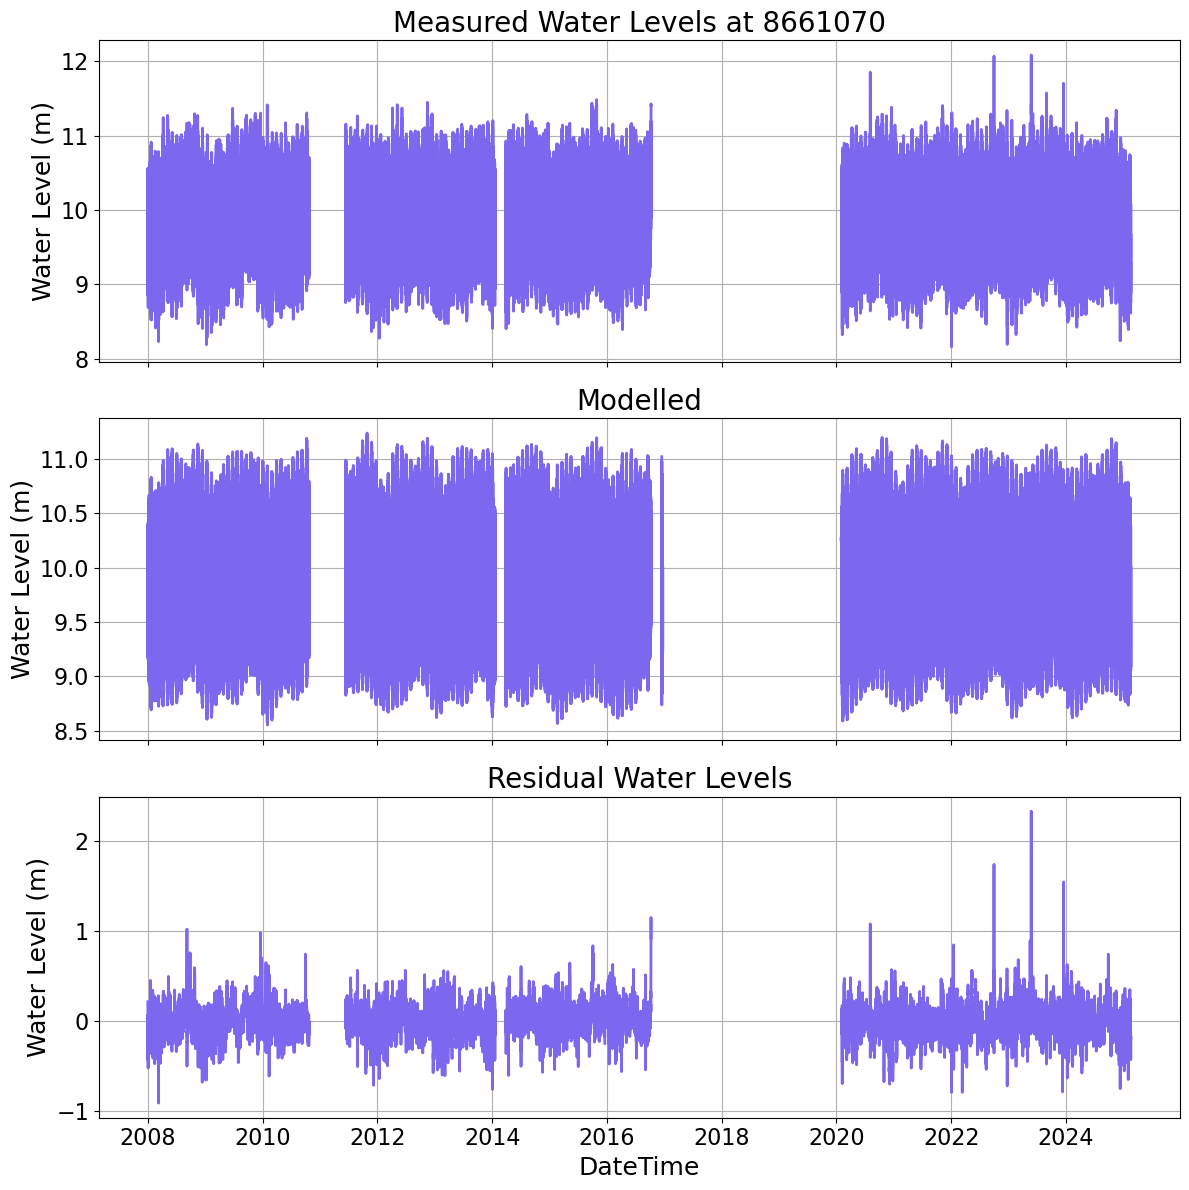

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import numpy as np

# Define the folder path
folder_path = "/Users/jenmontano/Duke/data/tides"

# Get list of CSV files
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
# Set font sizes
TITLE_SIZE = 20
AXIS_LABEL_SIZE = 18
TICK_LABEL_SIZE = 16
LEGEND_SIZE = 12
TEXT_SIZE = 14
color = 'mediumslateblue'

# Loop through each CSV file
for file in csv_files:
    # Read the CSV file
    df = pd.read_csv(file, sep="\t", skiprows=12, header=None, 
                     names=["datetime", "waterlevel_quality_controlled", "waterlevel_modelled", "waterlevel_residual"])
    
    # Convert datetime and set as index
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    
    # Replace 9999 values with NaN
    df = df.replace(9999, np.nan)
    
    # Downsample to 30-minute intervals
    df.set_index('datetime', inplace=True)
    df = df.resample('30T').mean()
    df.reset_index(inplace=True)
    
    # Get location name from filename

    location = os.path.basename(file).split('_')[0]
    # Create figure with three subplots
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
    
    # Plot 1: Measured Water Levels
    ax1.plot(df['datetime'], df['waterlevel_quality_controlled'], 
            label='Measured', linewidth=2, color=color)
    ax1.set_title(f'Measured Water Levels at {location}', fontsize=TITLE_SIZE)
    ax1.set_ylabel('Water Level (m)', fontsize=AXIS_LABEL_SIZE)
    ax1.grid(True)
    ax1.tick_params(axis='both', labelsize=TICK_LABEL_SIZE)
    
    # Plot 2: Modelled Water Levels
    ax2.plot(df['datetime'], df['waterlevel_modelled'], 
            label='Modelled', linewidth=2, color=color)
    ax2.set_title('Modelled', fontsize=TITLE_SIZE)
    ax2.set_ylabel('Water Level (m)', fontsize=AXIS_LABEL_SIZE)
    ax2.grid(True)
    ax2.tick_params(axis='both', labelsize=TICK_LABEL_SIZE)
   
    
    # Plot 3: Residual Water Levels
    ax3.plot(df['datetime'], df['waterlevel_residual'], 
            label='Residual', linewidth=2, color= color)
    ax3.set_title('Residual Water Levels', fontsize=TITLE_SIZE)
    ax3.set_xlabel('DateTime', fontsize=AXIS_LABEL_SIZE)
    ax3.set_ylabel('Water Level (m)', fontsize=AXIS_LABEL_SIZE)
    ax3.grid(True)
    ax3.tick_params(axis='both', labelsize=TICK_LABEL_SIZE)
    
    # Adjust layout
    plt.tight_layout()
    
    # Show the plot
    plt.show()
    
    # Clear the current figure
    plt.close()

#     plt.close()